# Loan Application Scoring & Data Cleaning with Python

## Project Overview

This project focuses on cleaning loan application data, enriching it with industry-based scores, and calculating an application score based on predefined business rules.

The main objectives of this project are:

- Clean and preprocess raw application data
- Handle missing values and duplicates
- Merge external industry score data
- Build a rule-based scoring system
- Identify accepted applications
- Analyze weekly trends of accepted applicants

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

## Business Context

In real-world scenarios, financial institutions evaluate loan applications based on multiple criteria. This project simulates a simplified scoring system used to assess applicants and make acceptance decisions.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
applications = pd.read_csv("applications.csv")
industries = pd.read_csv("industries.csv")

In [51]:
applications.head()

,Applied at,Amount,Age,Gender,Industry,Marital status,External Rating,Education level,Location,applicant_id
0,11.30.2022 10:26:37,12000.0,29,Чоловік,Blockchain,Other,8.0,"Вища (бакалавр, спеціаліст, магістр)",Івано-Франківськ чи область,99e7b0dc6cc05dd334d8f38dc26ce9b3
1,11.30.2022 10:26:39,NaN,36,Чоловік,Public services / Government,Single,3.0,"Вища (бакалавр, спеціаліст, магістр)",NaN,63dfcf8e6904186650d6814279fbe42f
2,11.30.2022 10:26:58,7500.0,34,Чоловік,Adtech / Advertising,Single,4.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,10dbafaeb46c09e96b6987c03bbb3498
3,11.30.2022 10:27:31,1500.0,23,Жінка,Telecom,Single,0.0,"Вища (бакалавр, спеціаліст, магістр)",Львів чи область,5847ac62cc9eac5e323c2517dcc91ad1
4,11.30.2022 10:27:34,8400.0,33,Жінка,Automotive,Single,6.0,"Вища (бакалавр, спеціаліст, магістр)",Житомир чи область,5d21f3795b50de8e8f8f8d5f48b754f3


In [52]:
industries.head()

,Industry,Score
0,Blockchain,0
1,Public services / Government,20
2,Adtech / Advertising,10
3,Telecom,15
4,Automotive,15


In [53]:
applications.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13315 entries, 0 to 13314
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Applied at       13315 non-null  object 
 1   Amount           13272 non-null  float64
 2   Age              13315 non-null  int64  
 3   Gender           13315 non-null  object 
 4   Industry         13315 non-null  object 
 5   Marital status   13315 non-null  object 
 6   External Rating  13243 non-null  float64
 7   Education level  13282 non-null  object 
 8   Location         11540 non-null  object 
 9   applicant_id     13315 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 1.0+ MB


In [54]:
applications.describe()

,Amount,Age,External Rating
count,13272.000000,13315.000000,13243.000000
mean,9034.665913,29.318288,4.882202
std,6168.343738,6.031209,3.738651
min,150.000000,14.000000,0.000000
25%,3900.000000,25.000000,2.000000
50%,7800.000000,29.000000,4.000000
75%,12900.000000,33.000000,7.000000
max,58500.000000,63.000000,15.000000


## Initial Data Exploration

We explored the datasets to understand their structure, data types, and identify missing values before performing data cleaning.

## Key Observations

- The `Amount` column contains missing values and has a wide range (from 150 to 58,500), indicating potential outliers.
- The average applicant age is around 29, with a range between 14 and 63.
- The `External Rating` varies significantly (0 to 15), and includes missing values.
- Some columns such as `Location` and `Education level` also contain missing values.
- Data cleaning will be necessary before building the scoring system.

In [55]:
applications.duplicated(subset='applicant_id').sum()

np.int64(37)

In [56]:
applications = applications.drop_duplicates(subset='applicant_id')
print(applications.head())

            Applied at   Amount  Age   Gender                      Industry  \
0  11.30.2022 10:26:37  12000.0   29  Чоловік                    Blockchain   
1  11.30.2022 10:26:39      NaN   36  Чоловік  Public services / Government   
2  11.30.2022 10:26:58   7500.0   34  Чоловік          Adtech / Advertising   
3  11.30.2022 10:27:31   1500.0   23    Жінка                       Telecom   
4  11.30.2022 10:27:34   8400.0   33    Жінка                    Automotive   

  Marital status  External Rating                       Education level  \
0          Other              8.0  Вища (бакалавр, спеціаліст, магістр)   
1         Single              3.0  Вища (бакалавр, спеціаліст, магістр)   
2         Single              4.0  Вища (бакалавр, спеціаліст, магістр)   
3         Single              0.0  Вища (бакалавр, спеціаліст, магістр)   
4         Single              6.0  Вища (бакалавр, спеціаліст, магістр)   

                      Location                      applicant_id  
0  Іван

In [57]:
applications.duplicated(subset='applicant_id').sum()

np.int64(0)

In [58]:
before = len(applications)

applications = applications.drop_duplicates(subset='applicant_id')

after = len(applications)

print("Removed rows:", before - after)

Removed rows: 0


## Handling Duplicate Records

We identified 37 duplicate records based on `applicant_id`.  
These duplicates were removed to ensure each applicant is represented only once.

A total of 37 rows were removed from the dataset, improving data quality and preventing biased analysis.
These duplicates were removed to ensure each applicant is represented only once in the dataset, preventing biased analysis and incorrect scoring.

In [59]:
applications.isnull().sum()

Applied at            0
Amount               33
Age                   0
Gender                0
Industry              0
Marital status        0
External Rating      72
Education level      33
Location           1772
applicant_id          0
dtype: int64

In [60]:
applications['External Rating'] = applications['External Rating'].fillna(0)

applications['Education level'] = applications['Education level'].fillna("Ortaokul")

In [61]:
applications.isnull().sum()

Applied at            0
Amount               33
Age                   0
Gender                0
Industry              0
Marital status        0
External Rating       0
Education level       0
Location           1772
applicant_id          0
dtype: int64

In [62]:
applications_raw = pd.read_csv("applications.csv")

missing_before = applications_raw.isnull().sum()

applications['External Rating'] = applications['External Rating'].fillna(0)
applications['Education level'] = applications['Education level'].fillna("Ortaokul")

missing_after = applications.isnull().sum()

print("Missing BEFORE:\n", missing_before)
print("\nMissing AFTER:\n", missing_after)

Missing BEFORE:
 Applied at            0
Amount               43
Age                   0
Gender                0
Industry              0
Marital status        0
External Rating      72
Education level      33
Location           1775
applicant_id          0
dtype: int64

Missing AFTER:
 Applied at            0
Amount               33
Age                   0
Gender                0
Industry              0
Marital status        0
External Rating       0
Education level       0
Location           1772
applicant_id          0
dtype: int64


## Handling Missing Values

Missing values were handled based on business logic and project requirements.

Before data cleaning:
- External Rating had 72 missing values
- Education level had 43 missing values
- Amount had 33 missing values
- Location had 1772 missing values

Actions taken:
- Missing values in `External Rating` were filled with 0, as required by the scoring rules.
- Missing values in `Education level` were filled with "Ortaokul".
- Missing values in `Amount` were intentionally left unchanged, since missing amounts directly result in a score of 0.
- Missing values in `Location` were not modified, as they do not critically impact the scoring logic.

After cleaning:
- External Rating → 0 missing values
- Education level → 0 missing values

This approach ensures that the dataset is both clean and aligned with business rules, preventing incorrect scoring and preserving data integrity.

- The number of missing values in the `Amount` and `Location` columns decreased after removing duplicate records, indicating that some duplicates also contained missing data.

In [63]:
applications['Industry'].head()

0                      Blockchain
1    Public services / Government
2            Adtech / Advertising
3                         Telecom
4                      Automotive
Name: Industry, dtype: object

In [64]:
industries.head()

,Industry,Score
0,Blockchain,0
1,Public services / Government,20
2,Adtech / Advertising,10
3,Telecom,15
4,Automotive,15


In [65]:
applications = applications.merge(
    industries,
    on='Industry',
    how='left'
)

applications.head()

,Applied at,Amount,Age,Gender,Industry,Marital status,External Rating,Education level,Location,applicant_id,Score
0,11.30.2022 10:26:37,12000.0,29,Чоловік,Blockchain,Other,8.0,"Вища (бакалавр, спеціаліст, магістр)",Івано-Франківськ чи область,99e7b0dc6cc05dd334d8f38dc26ce9b3,0
1,11.30.2022 10:26:39,NaN,36,Чоловік,Public services / Government,Single,3.0,"Вища (бакалавр, спеціаліст, магістр)",NaN,63dfcf8e6904186650d6814279fbe42f,20
2,11.30.2022 10:26:58,7500.0,34,Чоловік,Adtech / Advertising,Single,4.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,10dbafaeb46c09e96b6987c03bbb3498,10
3,11.30.2022 10:27:31,1500.0,23,Жінка,Telecom,Single,0.0,"Вища (бакалавр, спеціаліст, магістр)",Львів чи область,5847ac62cc9eac5e323c2517dcc91ad1,15
4,11.30.2022 10:27:34,8400.0,33,Жінка,Automotive,Single,6.0,"Вища (бакалавр, спеціаліст, магістр)",Житомир чи область,5d21f3795b50de8e8f8f8d5f48b754f3,15


In [66]:
applications['Score'].isnull().sum()

np.int64(0)

In [67]:
applications[['Industry', 'Score']].drop_duplicates().head(10)

,Industry,Score
0,Blockchain,0
1,Public services / Government,20
2,Adtech / Advertising,10
3,Telecom,15
4,Automotive,15
5,E-commerce,15
6,Media,5
9,Інша,10
10,Dating,5
11,Edtech / Education,15


## Merging Industry Scores

The cleaned application dataset was enriched with industry-based scores by merging it with the industry reference table.

A left merge was used on the `Industry` column to preserve all application records while adding the corresponding industry score.

This step allows the scoring system to include industry-level evaluation as one of the application score components.

To validate the merge, unique combinations of Industry and Score were inspected to ensure that each industry was correctly mapped to its corresponding score.

In [68]:
applications['Applied at'] = pd.to_datetime(
    applications['Applied at'],
    format='mixed',
    dayfirst=True
)

applications['Applied at'].head()

0   2022-11-30 10:26:37
1   2022-11-30 10:26:39
2   2022-11-30 10:26:58
3   2022-11-30 10:27:31
4   2022-11-30 10:27:34
Name: Applied at, dtype: datetime64[ns]

In [69]:
applications['score_age'] = (
    (applications['Age'] >= 35) & (applications['Age'] <= 55)
) * 20

In [70]:
applications['is_weekend'] = applications['Applied at'].dt.weekday >= 5

applications['score_weekend'] = (~applications['is_weekend']) * 20

In [71]:
applications['score_marital'] = (applications['Marital status'] == 'Married') * 20

In [72]:
applications['score_location'] = applications['Location'].str.contains('Київ', na=False) * 10

In [73]:
applications['score_industry'] = applications['Score']

In [74]:
applications['score_rating_high'] = (applications['External Rating'] >= 7) * 20
applications['score_rating_low'] = (applications['External Rating'] <= 2) * -20

In [75]:
applications['Total Score'] = (
    applications['score_age'] +
    applications['score_weekend'] +
    applications['score_marital'] +
    applications['score_location'] +
    applications['score_industry'] +
    applications['score_rating_high'] +
    applications['score_rating_low']
)

In [76]:
applications.loc[
    (applications['Amount'].isnull()) | (applications['External Rating'] == 0),
    'Total Score'
] = 0

In [77]:
accepted = applications[applications['Total Score'] > 0]

## Application Scoring System

A rule-based scoring model was implemented to evaluate loan applications.

Each applicant was scored based on:
- Age criteria
- Application timing (weekday vs weekend)
- Marital status
- Location (Kiev-based applicants)
- Industry score
- External rating

Business rules were applied to ensure:
- Missing financial data leads to score = 0
- Low external rating penalizes the applicant

This scoring system simulates a simplified credit decision model used in financial institutions.

In [78]:
accepted = applications[applications['Total Score'] > 0]

accepted.head()

,Applied at,Amount,Age,Gender,Industry,Marital status,External Rating,Education level,Location,applicant_id,Score,score_age,is_weekend,score_weekend,score_marital,score_location,score_industry,score_rating_high,score_rating_low,Total Score
0,2022-11-30 10:26:37,12000.0,29,Чоловік,Blockchain,Other,8.0,"Вища (бакалавр, спеціаліст, магістр)",Івано-Франківськ чи область,99e7b0dc6cc05dd334d8f38dc26ce9b3,0,0,False,20,0,0,0,20,0,40
2,2022-11-30 10:26:58,7500.0,34,Чоловік,Adtech / Advertising,Single,4.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,10dbafaeb46c09e96b6987c03bbb3498,10,0,False,20,0,10,10,0,0,40
4,2022-11-30 10:27:34,8400.0,33,Жінка,Automotive,Single,6.0,"Вища (бакалавр, спеціаліст, магістр)",Житомир чи область,5d21f3795b50de8e8f8f8d5f48b754f3,15,0,False,20,0,0,15,0,0,35
5,2022-11-30 10:27:38,16500.0,31,Чоловік,E-commerce,Single,8.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,f720bf9c5c4c3e10a8568c1699847696,15,0,False,20,0,10,15,20,0,65
6,2022-11-30 10:27:42,4200.0,30,Чоловік,Media,Married,1.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,0aaf59fb3ef90f50ccd4800312e5c271,5,0,False,20,20,10,5,0,-20,35


In [88]:
accepted = applications[applications['Total Score'] > 0].copy()

In [89]:
accepted['Application Week'] = accepted['Applied at'].dt.to_period('W').dt.start_time

In [90]:
weekly_score = accepted.groupby('Application Week')['Total Score'].mean()

weekly_score.head()

Application Week
2022-01-10    56.988555
2022-02-07    37.040498
2022-03-07    35.277778
2022-04-11    53.174905
2022-05-09    50.182584
Name: Total Score, dtype: float64

## Weekly Average Score Analysis

Accepted applications were grouped by application week, and the average score was calculated for each week.

This visualization helps identify how the quality of accepted applications changes over time and provides a simple way to monitor weekly applicant trends.

In [92]:
print("Total applications:", len(applications))
print("Accepted applications:", len(accepted))
print("Acceptance rate:", round(len(accepted) / len(applications) * 100, 2), "%")

Total applications: 13278
Accepted applications: 12519
Acceptance rate: 94.28 %


In [94]:
weekly_score = weekly_score.sort_index()

## Weekly Trend Analysis

To understand how application quality changes over time, we grouped accepted applications by week and calculated the average score.

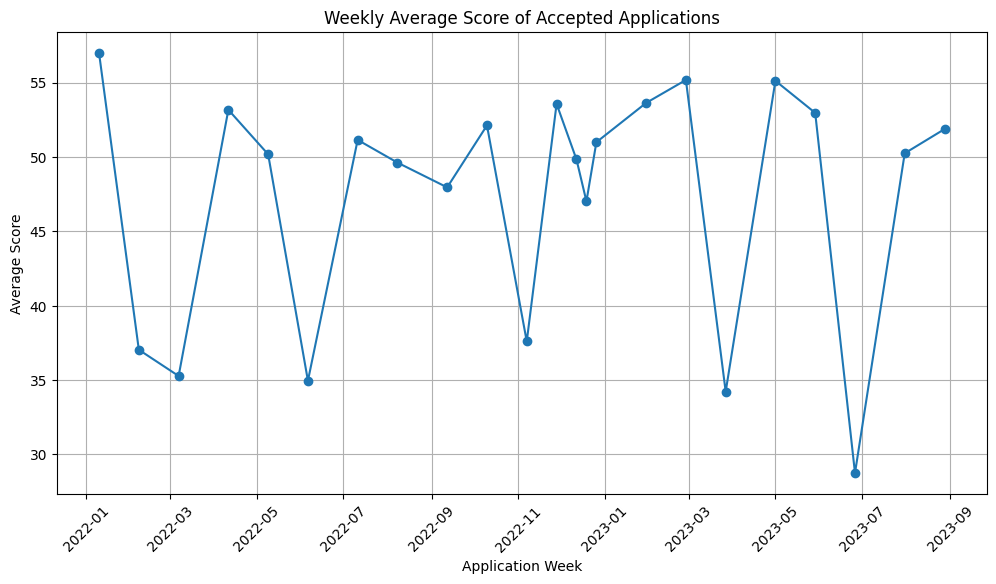

In [95]:
plt.figure(figsize=(12, 6))

plt.plot(weekly_score.index, weekly_score.values, marker='o')

plt.title('Weekly Average Score of Accepted Applications')
plt.xlabel('Application Week')
plt.ylabel('Average Score')

plt.xticks(rotation=45)
plt.grid()

plt.show()

## Weekly Average Score Analysis

Accepted applications were grouped by application week, and the average score was calculated for each week.

The chart shows fluctuations in applicant quality over time, indicating that the profile strength of accepted applicants varies across different periods.

Peaks in the graph represent weeks with stronger applicant profiles, while drops may indicate periods with lower-quality applications or changes in underlying data patterns.

This type of analysis can help businesses monitor trends and adjust decision strategies accordingly.

The acceptance rate is relatively high due to the simplified scoring logic used in this project. In real-world scenarios, stricter rules would typically be applied.

## Final Summary

This project successfully:

- Cleaned and preprocessed raw application data
- Handled missing values and duplicate records
- Enriched the dataset with industry-level scores
- Built a rule-based scoring system
- Identified accepted applications
- Analyzed weekly trends in applicant quality

The results demonstrate how business rules can be translated into data-driven decision systems.